In [1]:
import math
import os
from pathlib import Path

try:
    import requests
except ModuleNotFoundError:
    import sys
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "requests"])
    import requests

try:
    from dotenv import load_dotenv
except ModuleNotFoundError:
    import sys
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "python-dotenv"])
    from dotenv import load_dotenv

# Base URL for the LTA DataMall service
# Example endpoint: Bus Stops Data
url = "https://datamall2.mytransport.sg/ltaodataservice/v3/BusStops"
legacy_url = "https://datamall2.mytransport.sg/ltaodataservice/BusStops"
DEFAULT_API_KEY = "default_key_placeholder"  # Replace with your actual API key or set via .env
ENV_FILE = Path(".env")
CURRENT_TEST_LOCATION = (1.3331467739826808, 103.72190758075176)  # Jurong West coordinates for testing

def save_api_key_to_env(api_key_value, env_file=ENV_FILE):
    env_path = Path(env_file)
    env_path.touch(exist_ok=True)

    lines = env_path.read_text(encoding="utf-8").splitlines()
    new_lines = []
    found = False

    for line in lines:
        if line.startswith("LTA_ACCOUNT_KEY="):
            new_lines.append(f"LTA_ACCOUNT_KEY={api_key_value}")
            found = True
        else:
            new_lines.append(line)

    if not found:
        new_lines.append(f"LTA_ACCOUNT_KEY={api_key_value}")

    env_path.write_text("\n".join(new_lines).strip() + "\n", encoding="utf-8")
    os.environ["LTA_ACCOUNT_KEY"] = api_key_value


def load_api_key_from_env(env_file=ENV_FILE, fallback=None):
    env_path = Path(env_file)
    if env_path.exists():
        load_dotenv(dotenv_path=env_path, override=True)

    value = os.getenv("LTA_ACCOUNT_KEY")
    if not value and fallback:
        value = fallback
        os.environ["LTA_ACCOUNT_KEY"] = value

    if not value:
        raise RuntimeError(
            "LTA_ACCOUNT_KEY is missing. Set it in .env or call save_api_key_to_env(your_key)."
        )
    return value


# Ensure .env exists and contains LTA_ACCOUNT_KEY.
if not ENV_FILE.exists() or "LTA_ACCOUNT_KEY=" not in ENV_FILE.read_text(encoding="utf-8"):
    save_api_key_to_env(DEFAULT_API_KEY)

api_key = load_api_key_from_env(fallback=DEFAULT_API_KEY)
headers = {
    "AccountKey": api_key,
    "accept": "application/json"
}

def get_all_bus_stops(api_key):
    headers = {"AccountKey": api_key, "accept": "application/json"}
    all_stops = []
    skip = 0
    selected_url = None

    while True:
        # Loop to handle 500-record API limit
        params = {"$skip": skip} if skip > 0 else {}

        candidate_urls = [selected_url] if selected_url else [url, legacy_url]
        last_response = None

        for candidate_url in candidate_urls:
            response = requests.get(candidate_url, headers=headers, params=params, timeout=20)
            last_response = response
            if response.status_code == 404 and candidate_url == url:
                # Fallback if v3 endpoint is unavailable in the current account/region.
                continue
            selected_url = candidate_url
            break

        if last_response is None:
            raise RuntimeError("No request was made to DataMall API.")

        if last_response.status_code != 200:
            raise RuntimeError(
                f"LTA DataMall request failed (status={last_response.status_code}). "
                f"Body preview: {last_response.text[:300].strip()}"
            )

        try:
            payload = last_response.json()
        except ValueError as exc:
            raise RuntimeError(
                "LTA DataMall returned a non-JSON response. "
                f"Body preview: {last_response.text[:300].strip()}"
            ) from exc

        stops = payload.get("value", [])
        if not isinstance(stops, list):
            raise RuntimeError(
                "Unexpected API payload: expected key 'value' with a list. "
                f"Received keys: {list(payload.keys())}"
            )

        if not stops:
            break

        all_stops.extend(stops)
        skip += 500

    return all_stops

def haversine(lat1, lon1, lat2, lon2):
    # Calculates distance in meters between two coordinates
    R = 6371000
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)

    a = math.sin(delta_phi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda / 2) ** 2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

def find_nearby_bus_stops(my_lat, my_lon, api_key, max_distance_meters=200):
    stops = get_all_bus_stops(api_key)
    nearby = []

    for stop in stops:
        dist = haversine(my_lat, my_lon, stop['Latitude'], stop['Longitude'])
        if dist <= max_distance_meters:
            stop['Distance_Meters'] = round(dist)
            nearby.append(stop)

    # Sort by closest first
    return sorted(nearby, key=lambda x: x['Distance_Meters'])

# Example Usage (Jurong West coordinates)

# print(find_nearby_bus_stops(1.3404, 103.7090, api_key))

In [2]:
# get test location's nearby bus stops
current_lat, current_lon = CURRENT_TEST_LOCATION

# Find nearby bus stops
nearby_stops = find_nearby_bus_stops(current_lat, current_lon, api_key)
print(nearby_stops)

[{'BusStopCode': '21199', 'RoadName': 'Corporation Rd', 'Description': 'Blk 178', 'Latitude': 1.333309472028, 'Longitude': 103.72051292839538, 'Distance_Meters': 156}, {'BusStopCode': '21191', 'RoadName': 'Corporation Rd', 'Description': 'Opp Blk 178', 'Latitude': 1.33290982216515, 'Longitude': 103.72044541450344, 'Distance_Meters': 165}, {'BusStopCode': '21581', 'RoadName': 'Corporation Dr', 'Description': 'Blk 65', 'Latitude': 1.33243350969467, 'Longitude': 103.72328639029729, 'Distance_Meters': 173}, {'BusStopCode': '21589', 'RoadName': 'Corporation Dr', 'Description': 'Opp Blk 65', 'Latitude': 1.33246568746472, 'Longitude': 103.72345805167676, 'Distance_Meters': 188}, {'BusStopCode': '21591', 'RoadName': 'Corporation Dr', 'Description': 'Opp Blk 117', 'Latitude': 1.33476103645994, 'Longitude': 103.72242808341083, 'Distance_Meters': 189}, {'BusStopCode': '21599', 'RoadName': 'Corporation Dr', 'Description': 'Blk 117', 'Latitude': 1.33468356164521, 'Longitude': 103.72268493639599, 'D

In [3]:
import sys
import subprocess

try:
    import folium
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "folium"])
    import folium

# Center map at current location
m = folium.Map(location=[current_lat, current_lon], zoom_start=16)

# Marker for current location
folium.Marker(
    [current_lat, current_lon],
    popup="Current Location",
    tooltip="You are here",
    icon=folium.Icon(color="blue", icon="user")
).add_to(m)

# Mark nearby bus stops
for stop in nearby_stops:
    folium.Marker(
        [stop["Latitude"], stop["Longitude"]],
        popup=(
            f'{stop["Description"]} ({stop["BusStopCode"]})<br>'
            f'Road: {stop["RoadName"]}<br>'
            f'Distance: {stop["Distance_Meters"]} m'
        ),
        tooltip=stop["Description"],
        icon=folium.Icon(color="green", icon="bus", prefix="fa")
    ).add_to(m)

m

In [5]:
try:
    import requests
except ModuleNotFoundError:
    import sys
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "requests"])
    import requests

import os

# Base URL for the LTA DataMall service
# Example endpoint: Bus Arrival Data
url = "https://datamall2.mytransport.sg/ltaodataservice/v3/BusArrival"

# Reuse the resolved API key from the earlier setup cell when available.
resolved_api_key = globals().get("api_key") or os.getenv("LTA_ACCOUNT_KEY") or DEFAULT_API_KEY
if resolved_api_key == DEFAULT_API_KEY:
    raise RuntimeError("LTA_ACCOUNT_KEY is not configured. Set a real key in .env or call save_api_key_to_env(your_key) before running this cell.")

headers = {
    "AccountKey": resolved_api_key,
    "accept": "application/json"
}

# Optional parameters depending on the endpoint (e.g., BusStopCode)
query_params = {
    "BusStopCode": "21191"
}

try:
    response = requests.get(url, headers=headers, params=query_params, timeout=20)

    # Check if request was successful
    if response.status_code == 200:
        data = response.json()
        print(data)
    else:
        print(f"Failed with Status Code: {response.status_code}")
        print(response.text)

except Exception as e:
    print(f"An error occurred: {e}")


{'odata.metadata': 'https://datamall2.mytransport.sg/ltaodataservice/v3/BusArrival', 'BusStopCode': '21191', 'Services': [{'ServiceNo': '178', 'Operator': 'SMRT', 'NextBus': {'OriginCode': '46009', 'DestinationCode': '22009', 'EstimatedArrival': '2026-05-30T21:57:05+08:00', 'Monitored': 1, 'Latitude': '1.3266026666666666', 'Longitude': '103.74571166666666', 'VisitNumber': '1', 'Load': 'SEA', 'Feature': 'WAB', 'Type': 'SD'}, 'NextBus2': {'OriginCode': '46009', 'DestinationCode': '22009', 'EstimatedArrival': '2026-05-30T22:13:40+08:00', 'Monitored': 1, 'Latitude': '1.349221', 'Longitude': '103.7532605', 'VisitNumber': '1', 'Load': 'SEA', 'Feature': 'WAB', 'Type': 'SD'}, 'NextBus3': {'OriginCode': '46009', 'DestinationCode': '22009', 'EstimatedArrival': '2026-05-30T22:26:30+08:00', 'Monitored': 1, 'Latitude': '1.3732735', 'Longitude': '103.76302133333333', 'VisitNumber': '1', 'Load': 'SEA', 'Feature': 'WAB', 'Type': 'SD'}}]}


Matplotlib is building the font cache; this may take a moment.


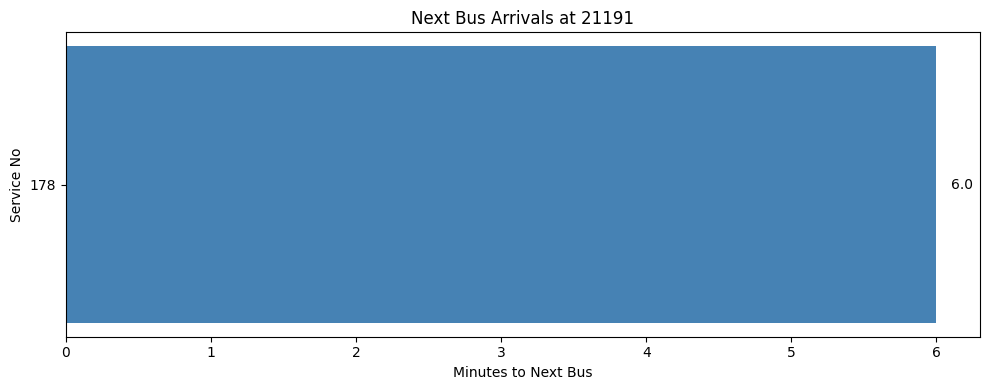

In [8]:
import pandas as pd

import matplotlib.pyplot as plt

services = data.get("Services", []) if isinstance(data, dict) else []

rows = []
now = pd.Timestamp.now(tz="UTC")

for svc in services:
    est = svc.get("NextBus", {}).get("EstimatedArrival")
    eta = pd.to_datetime(est, utc=True, errors="coerce") if est else pd.NaT
    if pd.notna(eta):
        minutes = max((eta - now).total_seconds() / 60, 0)
        rows.append({
            "ServiceNo": svc.get("ServiceNo", ""),
            "MinutesToNextBus": round(minutes, 1),
            "Load": svc.get("NextBus", {}).get("Load", "")
        })

df_arrivals = pd.DataFrame(rows)

if df_arrivals.empty:
    print("No arrival data available to plot.")
else:
    df_arrivals = df_arrivals.sort_values("MinutesToNextBus")

    plt.figure(figsize=(10, max(4, len(df_arrivals) * 0.45)))
    plt.barh(df_arrivals["ServiceNo"], df_arrivals["MinutesToNextBus"], color="steelblue")
    plt.xlabel("Minutes to Next Bus")
    plt.ylabel("Service No")
    plt.title(f"Next Bus Arrivals at {data.get('BusStopCode', '')}")
    plt.gca().invert_yaxis()

    for i, v in enumerate(df_arrivals["MinutesToNextBus"]):
        plt.text(v + 0.1, i, f"{v}", va="center")

    plt.tight_layout()
    plt.show()

In [9]:
services

[{'ServiceNo': '178',
  'Operator': 'SMRT',
  'NextBus': {'OriginCode': '46009',
   'DestinationCode': '22009',
   'EstimatedArrival': '2026-05-30T21:57:05+08:00',
   'Monitored': 1,
   'Latitude': '1.3266026666666666',
   'Longitude': '103.74571166666666',
   'VisitNumber': '1',
   'Load': 'SEA',
   'Feature': 'WAB',
   'Type': 'SD'},
  'NextBus2': {'OriginCode': '46009',
   'DestinationCode': '22009',
   'EstimatedArrival': '2026-05-30T22:13:40+08:00',
   'Monitored': 1,
   'Latitude': '1.349221',
   'Longitude': '103.7532605',
   'VisitNumber': '1',
   'Load': 'SEA',
   'Feature': 'WAB',
   'Type': 'SD'},
  'NextBus3': {'OriginCode': '46009',
   'DestinationCode': '22009',
   'EstimatedArrival': '2026-05-30T22:26:30+08:00',
   'Monitored': 1,
   'Latitude': '1.3732735',
   'Longitude': '103.76302133333333',
   'VisitNumber': '1',
   'Load': 'SEA',
   'Feature': 'WAB',
   'Type': 'SD'}}]